In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
train_dir = r"C:\Users\priya\project\TeaDs\train"
val_dir = r"C:\Users\priya\project\TeaDs\val"
image_size = 224
batch_size = 32
num_workers = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [15]:
classes = [label for _, label in train_dataset.imgs]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(classes), y=classes)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [16]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_classes = len(train_dataset.classes)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [19]:
num_epochs = 10 
for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")


Epoch 1/10 Train Loss: 1.0900 Train Acc: 0.6482 Val Loss: 0.4333 Val Acc: 0.8405
Epoch 2/10 Train Loss: 0.3720 Train Acc: 0.8827 Val Loss: 0.3471 Val Acc: 0.8727
Epoch 3/10 Train Loss: 0.2220 Train Acc: 0.9297 Val Loss: 0.3815 Val Acc: 0.8613
Epoch 4/10 Train Loss: 0.1521 Train Acc: 0.9551 Val Loss: 0.3013 Val Acc: 0.8984
Epoch 5/10 Train Loss: 0.0957 Train Acc: 0.9730 Val Loss: 0.3022 Val Acc: 0.9012
Epoch 6/10 Train Loss: 0.0511 Train Acc: 0.9843 Val Loss: 0.2733 Val Acc: 0.9145
Epoch 7/10 Train Loss: 0.0449 Train Acc: 0.9859 Val Loss: 0.2453 Val Acc: 0.9269
Epoch 8/10 Train Loss: 0.0326 Train Acc: 0.9924 Val Loss: 0.2478 Val Acc: 0.9259
Epoch 9/10 Train Loss: 0.0310 Train Acc: 0.9924 Val Loss: 0.2520 Val Acc: 0.9297
Epoch 10/10 Train Loss: 0.0218 Train Acc: 0.9949 Val Loss: 0.2481 Val Acc: 0.9231


In [20]:
torch.save(model.state_dict(), 'ResNet50.pth')

In [22]:
print(f"Train Acc: {sum((torch.max(model(x.to(device)),1)[1] == y.to(device)).sum().item() for x,y in train_loader)/len(train_loader.dataset):.4f} | Val Acc: {sum((torch.max(model(x.to(device)),1)[1] == y.to(device)).sum().item() for x,y in val_loader)/len(val_loader.dataset):.4f}")

Train Acc: 0.9995 | Val Acc: 0.9231


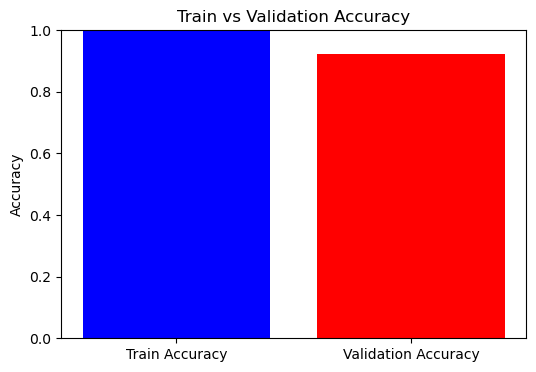

In [48]:
import matplotlib.pyplot as plt
train_acc = 0.9995
val_acc = 0.9231
labels = ['Train Accuracy', 'Validation Accuracy']
values = [train_acc, val_acc]
plt.figure(figsize=(6,4))
plt.bar(labels, values, color=['blue', 'red'])
plt.ylim(0, 1)
plt.title('Train vs Validation Accuracy')
plt.ylabel('Accuracy')
plt.show()

In [36]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [34]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

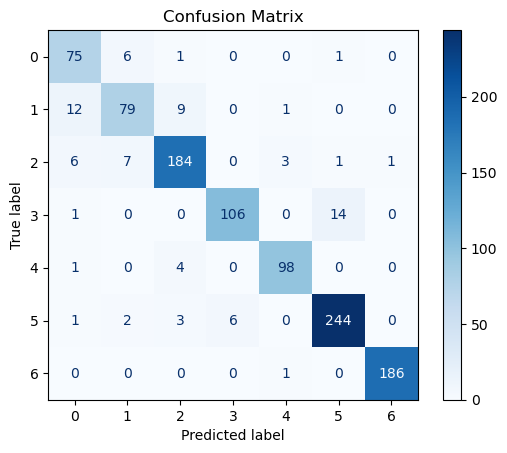

In [35]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [37]:
class_names = [
    "1. Tea algal leaf spot",
    "2. Brown Blight",
    "3. Gray Blight",
    "4. Helopeltis",
    "5. Red spider",
    "6. Green mirid bug",
    "7. Healthy leaf"
]
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
                         precision    recall  f1-score   support

1. Tea algal leaf spot       0.78      0.90      0.84        83
       2. Brown Blight       0.84      0.78      0.81       101
        3. Gray Blight       0.92      0.91      0.91       202
         4. Helopeltis       0.95      0.88      0.91       121
         5. Red spider       0.95      0.95      0.95       103
    6. Green mirid bug       0.94      0.95      0.95       256
       7. Healthy leaf       0.99      0.99      0.99       187

              accuracy                           0.92      1053
             macro avg       0.91      0.91      0.91      1053
          weighted avg       0.92      0.92      0.92      1053

